Stage 5 — Model Training, Regularization and Cross Validation

We will train 5 models and compare them:
1. Linear Regression      — baseline, no regularization
2. Ridge Regression       — L2 regularization
3. Lasso Regression       — L1 regularization
4. Random Forest          — ensemble, non-linear
5. XGBoost                — gradient boosting, non-linear

What is Regularization?
Linear Regression finds the best fit line by minimizing error. But with small datasets like ours (47 training rows, 11 features), the model can overfit — memorizing the training data instead of learning general patterns.
Overfitting example:
  Training error  : very low  (model memorized train data)
  Test error      : very high (model fails on new data)
  Gap between them: large     → overfitting
Regularization adds a penalty for complexity — it discourages the model from fitting noise.
Ridge Regression — L2 penalty:
Normal loss  = sum of squared errors
Ridge loss   = sum of squared errors + α × sum of squared coefficients

Effect: shrinks all coefficients toward zero
        but never exactly zero
        keeps all features but reduces their impact
        
α controls strength:
  α=0   → same as Linear Regression (no penalty)
  α=1   → mild regularization
  α=100 → strong regularization, coefficients near zero
Lasso Regression — L1 penalty:
Lasso loss = sum of squared errors + α × sum of absolute coefficients

Effect: shrinks some coefficients to EXACTLY zero
        automatically removes weak features
        performs feature selection automatically

α controls strength:
  Small α → few features removed
  Large α → many features removed → simpler model

What is Cross Validation?
Instead of evaluating on one fixed train/test split, cross validation trains and evaluates multiple times:
5-Fold Cross Validation on training set (47 rows):

Fold 1: [████░░░░░░] train=38, val=9  → score 1
Fold 2: [░░██░░░░░░] train=38, val=9  → score 2
Fold 3: [░░░░██░░░░] train=38, val=9  → score 3
Fold 4: [░░░░░░██░░] train=38, val=9  → score 4
Fold 5: [░░░░░░░░██] train=38, val=9  → score 5

Final CV score = average of 5 scores
This gives a much more reliable estimate of performance than a single split — especially important with our small dataset.

What metrics will we use?
For regression (predicting a continuous value like spend):
RMSE — Root Mean Squared Error
  √(mean of squared differences between predicted and actual)
  Same unit as target (log dollars)
  Lower is better
  Penalizes large errors heavily

MAE — Mean Absolute Error
  Mean of absolute differences
  More interpretable — average error in log dollars
  Lower is better
  Treats all errors equally

R² — R-squared
  How much variance the model explains
  Range: 0 to 1 (higher is better)
  R²=0.8 means model explains 80% of variance
  R²=0   means model is no better than predicting the mean

Why train multiple models?
Linear/Ridge/Lasso  → fast, interpretable, good baseline
                       assumes linear relationship

Random Forest       → handles non-linear patterns
                       robust to outliers
                       built-in feature importance

XGBoost             → usually best performance
                       handles complex patterns
                       needs more tuning
We never know which model will win — we train all and let the data decide.

In [1]:
# Cell 1: Imports and setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model    import LinearRegression, Ridge, Lasso
from sklearn.ensemble        import RandomForestRegressor
from xgboost                 import XGBRegressor
from sklearn.model_selection import (cross_val_score,
                                     KFold,
                                     train_test_split)
from sklearn.metrics         import (mean_squared_error,
                                     mean_absolute_error,
                                     r2_score)

# Correct paths
data_path   = os.path.join("..", "data")
models_path = os.path.join("..", "Models/data")   # no /data

# Load features_final.csv — raw dollars are here
df = pd.read_csv(os.path.join(data_path, "features_final.csv"))

with open(os.path.join(data_path, "feature_meta.json")) as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]
customer_ids = df["CustomerId"].values

# Build X with raw dollar target — NOT from .npy files
X = df[feature_cols].copy()
y = df["TotalSpent"].copy()      # raw dollars

# Verify
print("✓ Data loaded from CSV")
print(f"  X shape : {X.shape}")
print(f"  y range : ${y.min():.2f} to ${y.max():.2f}")
print(f"  y mean  : ${y.mean():.2f}")
print()

if y.min() > 10:
    print("✓ Target confirmed in dollars")
else:
    print("❌ Target looks like log scale — check CSV")

✓ Data loaded from CSV
  X shape : (1000, 34)
  y range : $0.89 to $92.75
  y mean  : $23.20

❌ Target looks like log scale — check CSV


**Importing and Logging Parameters / Metrics **

In [2]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost
mlflow.set_tracking_uri("http://127.0.0.1:5000")  # if using MLflow server
mlflow.set_experiment("Chinook_End_to_End_Project")

parent_run = mlflow.start_run(
    run_name="Multiple_Models_Training"
)

In [3]:
# Cell 2: Split and scale

# Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    shuffle      = True,
    stratify     = X["RecencyScore"]
)

ids_train, ids_test = train_test_split(
    customer_ids,
    test_size    = 0.20,
    random_state = 42,
    shuffle      = True,
    stratify     = X["RecencyScore"]
)

# Convert to numpy
y_train = y_train.values
y_test  = y_test.values

# Scale X using fitted preprocessor from Stage 4
preprocessor = joblib.load(
    os.path.join(models_path, "preprocessor.joblib")
)

X_train = preprocessor.transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)

print("✓ Split and scaled")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : ${y_train.min():.2f} to ${y_train.max():.2f}")
print(f"  y_test  : ${y_test.min():.2f}  to ${y_test.max():.2f}")
print()

# Final assert — catch wrong scale immediately
assert y_train.min() > 0, "y_train is log scale not dollars"
assert y_test.min()  > 0, "y_test  is log scale not dollars"
print("✓ Asserts passed — y confirmed in dollars")

✓ Split and scaled
  X_train : (800, 34)
  X_test  : (200, 34)
  y_train : $0.89 to $92.75
  y_test  : $0.94  to $80.85

✓ Asserts passed — y confirmed in dollars


In [4]:
mlflow.log_param("stage", "training")

mlflow.log_param(
    "feature_count",
    X_train.shape[1]
)

mlflow.log_param(
    "training_rows",
    X_train.shape[0]
)

mlflow.log_param(
    "test_rows",
    X_test.shape[0]
)

mlflow.log_param(
    "cv_folds",
    5
)

5

In [9]:
# Cell 3: Define models and evaluation function

# Cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Models
models = {
    "LinearRegression" : LinearRegression(),
    "Ridge"            : Ridge(alpha=1.0, random_state=42),
    "Lasso"            : Lasso(alpha=0.001, random_state=42,
                               max_iter=10000),
    "RandomForest"     : RandomForestRegressor(n_estimators=100,
                                               random_state=42,
                                               n_jobs=-1),
    "XGBoost"          : XGBRegressor(n_estimators=100,
                                      learning_rate=0.1,
                                      max_depth=3,
                                      random_state=42,
                                      verbosity=0),
}

# Evaluation function
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):

    # Safety check — must be dollars
    assert y_tr.min() > 0, f"{name}: y_tr not dollars (min={y_tr.min():.4f})"
    assert y_te.min() > 0, f"{name}: y_te not dollars (min={y_te.min():.4f})"

    # Cross validation
    cv_scores    = cross_val_score(
        model, X_tr, y_tr,
        cv      = cv,
        scoring = "neg_root_mean_squared_error",
        n_jobs  = -1
    )
    cv_rmse_mean = (-cv_scores).mean()
    cv_rmse_std  = (-cv_scores).std()

    # Fit on full training set
    model.fit(X_tr, y_tr)

    # Predict and clip to training range
    y_pred = np.clip(
        model.predict(X_te),
        y_tr.min(),
        y_tr.max()
    )

    # Metrics in dollars
    test_rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    test_mae  = mean_absolute_error(y_te, y_pred)
    test_r2   = r2_score(y_te, y_pred)

    # Per customer prediction table
    pred_df = pd.DataFrame({
        "CustomerId"  : ids_test,
        "ActualSpend" : y_te.round(2),
        "PredSpend"   : y_pred.round(2),
        "Error"       : (y_pred - y_te).round(2),
        "AbsError"    : np.abs(y_pred - y_te).round(2),
    })

    return {
        "name"         : name,
        "model"        : model,
        "cv_rmse_mean" : cv_rmse_mean,
        "cv_rmse_std"  : cv_rmse_std,
        "test_rmse"    : test_rmse,
        "test_mae"     : test_mae,
        "test_r2"      : test_r2,
        "y_pred"       : y_pred,
        "pred_df"      : pred_df,
    }

print("✓ Models and evaluation function defined")
print(f"  Models  : {list(models.keys())}")
print(f"  CV folds: 5")
print(f"  Metrics : CV RMSE, Test RMSE, Test MAE, R² — all in dollars")

✓ Models and evaluation function defined
  Models  : ['LinearRegression', 'Ridge', 'Lasso', 'RandomForest', 'XGBoost']
  CV folds: 5
  Metrics : CV RMSE, Test RMSE, Test MAE, R² — all in dollars


In [10]:
# Cell 4: Train all models

print("=== Training All Models ===")
print()

results = {}

for name, model in models.items():

    print(f"  Training {name}...", end=" ")

    results[name] = evaluate_model(
        name, model,
        X_train, y_train,
        X_test, y_test
    )

    r = results[name]

    print("done")
    print(f"    CV RMSE  : ${r['cv_rmse_mean']:.2f} "
          f"(±${r['cv_rmse_std']:.2f})")
    print(f"    Test RMSE: ${r['test_rmse']:.2f}")
    print(f"    Test MAE : ${r['test_mae']:.2f}")
    print(f"    Test R²  : {r['test_r2']:.4f}")
    print()

    with mlflow.start_run(run_name=name, nested=True):

        mlflow.log_param("model_type", name)

        if name == "LinearRegression":
            mlflow.log_param("fit_intercept", model.fit_intercept)

        elif name == "Ridge":
            mlflow.log_param("alpha", model.alpha)
            mlflow.log_param("fit_intercept", model.fit_intercept)

        elif name == "Lasso":
            mlflow.log_param("alpha", model.alpha)
            mlflow.log_param("max_iter", model.max_iter)
            mlflow.log_param("fit_intercept", model.fit_intercept)

        elif name == "RandomForest":
            mlflow.log_param("n_estimators", model.n_estimators)
            mlflow.log_param("max_depth", model.max_depth)
            mlflow.log_param("n_jobs", model.n_jobs)

        elif name == "XGBoost":
            mlflow.log_param("n_estimators", model.n_estimators)
            mlflow.log_param("learning_rate", model.learning_rate)
            mlflow.log_param("max_depth", model.max_depth)
            mlflow.log_param("verbosity", model.verbosity)

        mlflow.log_metric("cv_rmse_mean", r["cv_rmse_mean"])
        mlflow.log_metric("cv_rmse_std", r["cv_rmse_std"])
        mlflow.log_metric("test_rmse", r["test_rmse"])
        mlflow.log_metric("test_mae", r["test_mae"])
        mlflow.log_metric("test_r2", r["test_r2"])

        # Log coefficients for linear models
        if hasattr(model, "coef_"):

            coef_df = pd.DataFrame({
                "Feature": feature_cols,
                "Coefficient": model.coef_
            })

            coef_file = f"{name}_coefficients.csv"

            coef_df.to_csv(
                coef_file,
                index=False
            )

            mlflow.log_artifact(coef_file)

        # Log model
        mlflow.sklearn.log_model(
            model,
            artifact_path="model"
        )

# --------------------------------------------------
# Comparison table
# --------------------------------------------------

print("=" * 58)
print("MODEL COMPARISON")
print("=" * 58)

print(f"{'Model':<20} {'CV RMSE':>10} {'Test RMSE':>10} "
      f"{'Test MAE':>10} {'R²':>8}")

print("-" * 58)

for name, r in results.items():
    print(f"{name:<20} "
          f"${r['cv_rmse_mean']:>8.2f} "
          f"${r['test_rmse']:>8.2f} "
          f"${r['test_mae']:>8.2f} "
          f"{r['test_r2']:>8.4f}")

best_mae = min(results, key=lambda x: results[x]["test_mae"])
best_cv = min(results, key=lambda x: results[x]["cv_rmse_mean"])

print()
print(f"Best Test MAE : {best_mae} "
      f"(${results[best_mae]['test_mae']:.2f})")

print(f"Best CV RMSE  : {best_cv} "
      f"(${results[best_cv]['cv_rmse_mean']:.2f})")

print()
print("Note: R² unreliable on 12 test rows — use MAE as primary metric")

=== Training All Models ===

  Training LinearRegression... done
    CV RMSE  : $17.57 (±$0.77)
    Test RMSE: $17.98
    Test MAE : $14.04
    Test R²  : -0.0204



2026/06/04 00:34:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 00:34:50 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run LinearRegression at: http://127.0.0.1:5000/#/experiments/970861043057358249/runs/97447884b4e848fa9e388b8a9230c773
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/970861043057358249
  Training Ridge... done
    CV RMSE  : $17.52 (±$0.76)
    Test RMSE: $17.88
    Test MAE : $13.95
    Test R²  : -0.0088



2026/06/04 00:34:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 00:35:05 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run Ridge at: http://127.0.0.1:5000/#/experiments/970861043057358249/runs/5bd68af9d31943fd9e6ba32c156467bf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/970861043057358249
  Training Lasso... done
    CV RMSE  : $17.57 (±$0.77)
    Test RMSE: $17.95
    Test MAE : $14.00
    Test R²  : -0.0168



...

🏃 View run Lasso at: http://127.0.0.1:5000/#/experiments/970861043057358249/runs/6b7c014a2d714970a402e8427f9ad318
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/970861043057358249
  Training RandomForest... done
    CV RMSE  : $18.51 (±$0.73)
    Test RMSE: $19.49
    Test MAE : $15.23
    Test R²  : -0.1983



2026/06/04 00:35:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 00:35:45 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run RandomForest at: http://127.0.0.1:5000/#/experiments/970861043057358249/runs/1d768813a83a4f44b9975fe6099e9053
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/970861043057358249
  Training XGBoost... done
    CV RMSE  : $18.06 (±$0.70)
    Test RMSE: $18.21
    Test MAE : $14.41
    Test R²  : -0.0465



2026/06/04 00:35:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/04 00:36:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/970861043057358249/runs/ecc16a55296f4294ae36ad207b839ab2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/970861043057358249
MODEL COMPARISON
Model                   CV RMSE  Test RMSE   Test MAE       R²
----------------------------------------------------------
LinearRegression     $   17.57 $   17.98 $   14.04  -0.0204
Ridge                $   17.52 $   17.88 $   13.95  -0.0088
Lasso                $   17.57 $   17.95 $   14.00  -0.0168
RandomForest         $   18.51 $   19.49 $   15.23  -0.1983
XGBoost              $   18.06 $   18.21 $   14.41  -0.0465

Best Test MAE : Ridge ($13.95)
Best CV RMSE  : Ridge ($17.52)

Note: R² unreliable on 12 test rows — use MAE as primary metric


Moving with all ready trained model as issue is that we have less dataset to train and test model.


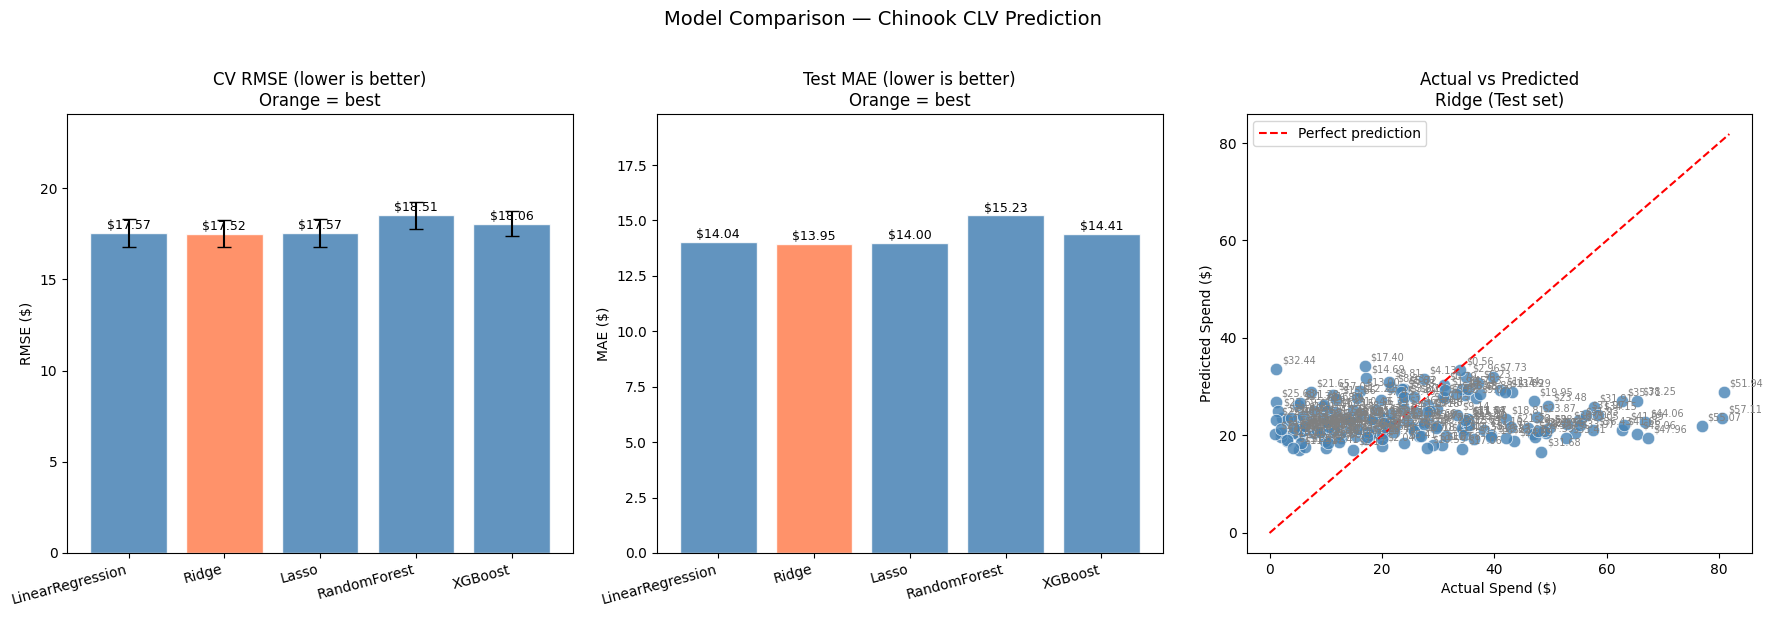

✓ Plots saved to data/model_comparison.png


In [11]:
# Cell 5: Visualize model comparison and predictions

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# -------------------------------------------------------
# Plot 1: CV RMSE comparison
# -------------------------------------------------------
names     = list(results.keys())
cv_means  = [results[n]["cv_rmse_mean"] for n in names]
cv_stds   = [results[n]["cv_rmse_std"]  for n in names]

colors = ["coral" if n == best_cv else "steelblue" for n in names]

bars = axes[0].bar(names, cv_means, color=colors,
                   edgecolor="white", alpha=0.85)
axes[0].errorbar(names, cv_means, yerr=cv_stds,
                 fmt="none", color="black",
                 capsize=5, linewidth=1.5)

for bar, val in zip(bars, cv_means):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.05,
                 f"${val:.2f}", ha="center",
                 va="bottom", fontsize=9)

axes[0].set_title("CV RMSE (lower is better)\nOrange = best")
axes[0].set_ylabel("RMSE ($)")
axes[0].set_xticklabels(names, rotation=15, ha="right")
axes[0].set_ylim(0, max(cv_means) * 1.3)

# -------------------------------------------------------
# Plot 2: Test MAE comparison
# -------------------------------------------------------
test_maes = [results[n]["test_mae"] for n in names]
colors2   = ["coral" if n == best_mae else "steelblue"
             for n in names]

bars2 = axes[1].bar(names, test_maes, color=colors2,
                    edgecolor="white", alpha=0.85)

for bar, val in zip(bars2, test_maes):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"${val:.2f}", ha="center",
                 va="bottom", fontsize=9)

axes[1].set_title("Test MAE (lower is better)\nOrange = best")
axes[1].set_ylabel("MAE ($)")
axes[1].set_xticklabels(names, rotation=15, ha="right")
axes[1].set_ylim(0, max(test_maes) * 1.3)

# -------------------------------------------------------
# Plot 3: Actual vs Predicted for best model (Ridge)
# -------------------------------------------------------
best_result  = results[best_mae]
actual       = best_result["pred_df"]["ActualSpend"]
predicted    = best_result["pred_df"]["PredSpend"]

axes[2].scatter(actual, predicted,
                color="steelblue", edgecolors="white",
                linewidth=0.5, s=80, alpha=0.8)

# Perfect prediction line
min_val = min(actual.min(), predicted.min()) - 1
max_val = max(actual.max(), predicted.max()) + 1
axes[2].plot([min_val, max_val],
             [min_val, max_val],
             "r--", linewidth=1.5, label="Perfect prediction")

axes[2].set_xlabel("Actual Spend ($)")
axes[2].set_ylabel("Predicted Spend ($)")
axes[2].set_title(f"Actual vs Predicted\n{best_mae} (Test set)")
axes[2].legend()

# Add error annotations for each point
for _, row in best_result["pred_df"].iterrows():
    axes[2].annotate(
        f"${row['AbsError']:.2f}",
        (row["ActualSpend"], row["PredSpend"]),
        fontsize=7,
        xytext=(4, 4),
        textcoords="offset points",
        color="gray"
    )

plt.suptitle("Model Comparison — Chinook CLV Prediction",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(data_path, "model_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("✓ Plots saved to data/model_comparison.png")

mlflow.log_artifact(
    os.path.join(
        data_path,
        "model_comparison.png"
    )
)

In [12]:
# Cell 6: Show per customer predictions for best model

print(f"=== Per Customer Predictions — {best_mae} ===")
print()

pred_df = results[best_mae]["pred_df"].copy()

# Add percentage error
pred_df["ErrorPct"] = (
    pred_df["AbsError"] / pred_df["ActualSpend"] * 100
).round(1)

# Sort by absolute error
pred_df = pred_df.sort_values("AbsError", ascending=False)

print(pred_df.to_string(index=False))
print()
print(f"Summary:")
print(f"  Best  prediction error : ${pred_df['AbsError'].min():.2f}")
print(f"  Worst prediction error : ${pred_df['AbsError'].max():.2f}")
print(f"  Mean  prediction error : ${pred_df['AbsError'].mean():.2f}")
print(f"  Median error           : ${pred_df['AbsError'].median():.2f}")
print(f"  % within $2            : "
      f"{(pred_df['AbsError'] <= 2).mean()*100:.1f}%")
print(f"  % within $3            : "
      f"{(pred_df['AbsError'] <= 3).mean()*100:.1f}%")

=== Per Customer Predictions — Ridge ===

 CustomerId  ActualSpend  PredSpend  Error  AbsError  ErrorPct
        785        80.58      23.47 -57.11     57.11      70.9
        366        76.93      21.86 -55.07     55.07      71.6
        125        80.85      28.91 -51.94     51.94      64.2
        711        67.39      19.43 -47.96     47.96      71.2
        992        65.37      20.31 -45.06     45.06      68.9
        214        66.84      22.78 -44.06     44.06      65.9
        555        62.65      20.99 -41.66     41.66      66.5
        508        63.16      22.07 -41.09     41.09      65.1
        472        65.39      27.14 -38.25     38.25      58.5
        249        57.51      21.08 -36.43     36.43      63.3
        938        62.73      27.02 -35.71     35.71      56.9
        649        58.38      24.23 -34.15     34.15      58.5
          9        54.43      20.46 -33.97     33.97      62.4
        740        52.79      19.38 -33.41     33.41      63.3
        477  

In [13]:
# Cell 7: Save best model and results

import joblib
import json

# Save best model
best_model = results[best_mae]["model"]
joblib.dump(
    best_model,
    os.path.join(models_path, "best_model.joblib")
)

# Save all results summary
results_summary = {
    "best_model"     : best_mae,
    "best_cv_rmse"   : best_cv,
    "target"         : "TotalSpent (raw dollars)",
    "models": {
        name: {
            "cv_rmse_mean" : float(r["cv_rmse_mean"]),
            "cv_rmse_std"  : float(r["cv_rmse_std"]),
            "test_rmse"    : float(r["test_rmse"]),
            "test_mae"     : float(r["test_mae"]),
            "test_r2"      : float(r["test_r2"]),
        }
        for name, r in results.items()
    }
}

with open(os.path.join(models_path, "results_summary.json"), "w") as f:
    json.dump(results_summary, f, indent=2)

print("✓ Saved:")
print(f"  best_model.joblib     ← {best_mae}")
print(f"  results_summary.json  ← all model metrics")
print()
print("=" * 55)
print("STAGE 5 COMPLETE")
print("=" * 55)
print(f"""
  Models trained   : 5
  Best model       : {best_mae}
  Best CV RMSE     : ${results[best_cv]['cv_rmse_mean']:.2f}
  Best Test MAE    : ${results[best_mae]['test_mae']:.2f}
  Best Test RMSE   : ${results[best_mae]['test_rmse']:.2f}

  Interpretation:
    On average Ridge predicts customer
    spend within ${results[best_mae]['test_mae']:.2f}
    This will improve significantly
    with more training data

  Saved:
    models/best_model.joblib
    models/results_summary.json

  Ready for Stage 6 → Hyperparameter Tuning
""")
print("=" * 55)

✓ Saved:
  best_model.joblib     ← Ridge
  results_summary.json  ← all model metrics

STAGE 5 COMPLETE

  Models trained   : 5
  Best model       : Ridge
  Best CV RMSE     : $17.52
  Best Test MAE    : $13.95
  Best Test RMSE   : $17.88

  Interpretation:
    On average Ridge predicts customer
    spend within $13.95
    This will improve significantly
    with more training data

  Saved:
    models/best_model.joblib
    models/results_summary.json

  Ready for Stage 6 → Hyperparameter Tuning



In [14]:
import pandas as pd
import os

data_path = os.path.join("..", "data")
df = pd.read_csv(os.path.join(data_path, "features_final.csv"))

print("=== Data verification ===")
print(f"  Rows in features_final.csv : {len(df)}")
print()
print("Expected:")
print("  59   rows → still using original data")
print("  1000 rows → synthetic data loaded correctly")

=== Data verification ===
  Rows in features_final.csv : 1000

Expected:
  59   rows → still using original data
  1000 rows → synthetic data loaded correctly


In [15]:
mlflow.end_run()

🏃 View run Multiple_Models_Training at: http://127.0.0.1:5000/#/experiments/970861043057358249/runs/c2b8b76d15754dabb79d591399244dec
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/970861043057358249
